# Baseline Preprocessing

- Goal: Understand the data before making preprocessing decisions.

## 1. Setup

- Import the libraries needed for inspection.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load Data

- Load the dataset from the project folder.

In [2]:
data_folder = "../dataset/creditcard.csv"
df = pd.read_csv(data_folder)


## 3. First Look

- Inspect the first few rows and confirm the dataset loaded correctly.

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 4. Shape and Columns

- Check the number of rows, number of columns, and feature names.

In [4]:
print("Shape of the dataset:",df.shape)
print(df.columns)

Shape of the dataset: (284807, 31)
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


## 5. Data Types

- Inspect column types and basic dataset structure.

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

- There are no Null entries. 
- 

## 6. Summary Statistics

- Review high-level statistics for numeric columns.

In [6]:
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

## 7. Target Distribution

- Measure how imbalanced the fraud labels are.

In [7]:
print("Value counts for Class column:\n",df["Class"].value_counts())
print("--------------------------------------------------------------------")
print("percentage of fraudulent transactions:", df["Class"].value_counts(normalize=True) * 100)


Value counts for Class column:
 Class
0    284315
1       492
Name: count, dtype: int64
--------------------------------------------------------------------
percentage of fraudulent transactions: Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


## 8. Missing Values

- Check whether any columns contain missing data.

In [8]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


## 9. Observations

Write down what stands out from the initial inspection.

- There seems to be no null values.
- High Class Imbalance is seen - 0.1727% of fraudulent cases

# Dataset Specific Preprocessing

Decide what preprocessing work should happen next

## 1. Check for Duplicates
- Inspect the dataset for any duplicate transactions

In [9]:
# print(df[df.duplicated()])
print(df[df.duplicated(keep=False)])
print("---------------------------------------------------------------")
print("NUMBER OF DUPLICATES:", df.duplicated().sum())

            Time        V1        V2        V3        V4        V5        V6  \
32          26.0 -0.529912  0.873892  1.347247  0.145457  0.414209  0.100223   
33          26.0 -0.529912  0.873892  1.347247  0.145457  0.414209  0.100223   
34          26.0 -0.535388  0.865268  1.351076  0.147575  0.433680  0.086983   
35          26.0 -0.535388  0.865268  1.351076  0.147575  0.433680  0.086983   
112         74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
...          ...       ...       ...       ...       ...       ...       ...   
283485  171627.0 -1.457978  1.378203  0.811515 -0.603760 -0.711883 -0.471672   
284190  172233.0 -2.667936  3.160505 -3.355984  1.007845 -0.377397 -0.109730   
284191  172233.0 -2.667936  3.160505 -3.355984  1.007845 -0.377397 -0.109730   
284192  172233.0 -2.691642  3.123168 -3.339407  1.017018 -0.293095 -0.167054   
284193  172233.0 -2.691642  3.123168 -3.339407  1.017018 -0.293095 -0.167054   

              V7        V8        V9  .

In real banking systems:

* same amount
* same timestamp
* same merchant

can happen.

But the probability that all PCA features are exactly identical is extremely low.

Since PCA values are continuous floats, exact duplicate full rows strongly suggest duplicated records.

Why duplicates are dangerous in ML

Duplicates can:

* leak information into train/test split
* inflate accuracy
* bias model toward repeated patterns
* worsen imbalance problems

Especially dangerous in fraud datasets because fraud class is tiny.

- Remove the duplicates

In [10]:
duplicates = df.shape[0]
print(df.shape)

df = df.drop_duplicates()

print(df.shape)
print(duplicates - df.shape[0])

(284807, 31)
(283726, 31)
1081


- Analyse the changes

In [11]:
print(df["Class"].value_counts())
df["Class"].value_counts(normalize=True) * 100

Class
0    283253
1       473
Name: count, dtype: int64


Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

Fraudulent cases dropped from 492 to 473(difference of 19) dropping the percentage to 0.1667

## 2. Time and Amount

- Inspect the two non-PCA-transformed features both together and separately.

In [12]:
print(df[["Time", "Amount"]].head())
print("--------------------------------------------------")
print(df[["Time", "Amount"]].describe())
print("--------------------------------------------------")
print("VALUE COUNTS\n",df[["Time", "Amount"]].value_counts().head())

   Time  Amount
0   0.0  149.62
1   0.0    2.69
2   1.0  378.66
3   1.0  123.50
4   2.0   69.99
--------------------------------------------------
                Time         Amount
count  283726.000000  283726.000000
mean    94811.077600      88.472687
std     47481.047891     250.399437
min         0.000000       0.000000
25%     54204.750000       5.600000
50%     84692.500000      22.000000
75%    139298.000000      77.510000
max    172792.000000   25691.160000
--------------------------------------------------
VALUE COUNTS
 Time     Amount
19912.0  5.0       13
19911.0  5.0       10
19913.0  5.0        9
19914.0  5.0        8
19909.0  5.0        7
Name: count, dtype: int64


### Amount Column

* mean = 88.47
    Average transaction amount is $88.47.
* std = 250.39
    Very high spread. Transactions vary a lot.
* min = 0
    Some transactions have $0 amount.
* 25% = 5.60
    25% of transactions are below $5.60.
* 50% = 22
    Median transaction is only $22. This is more important than mean here.
* 75% = 77.51
    75% of transactions are below $77.51.
* max = 25,691
    Massive outlier transactions exist.

The data is highly right-skewed:

* Most transactions are small.
* Few huge transactions pull the mean upward.

### Time column

This is seconds elapsed from the first transaction.

* min = 0
* max = 172,792

172,792 seconds ≈ 48 hours.

So dataset spans about 2 days of transactions.

Median:

* 84692 seconds ≈ 23.5 hours

Meaning transactions are fairly distributed across the 2-day period.


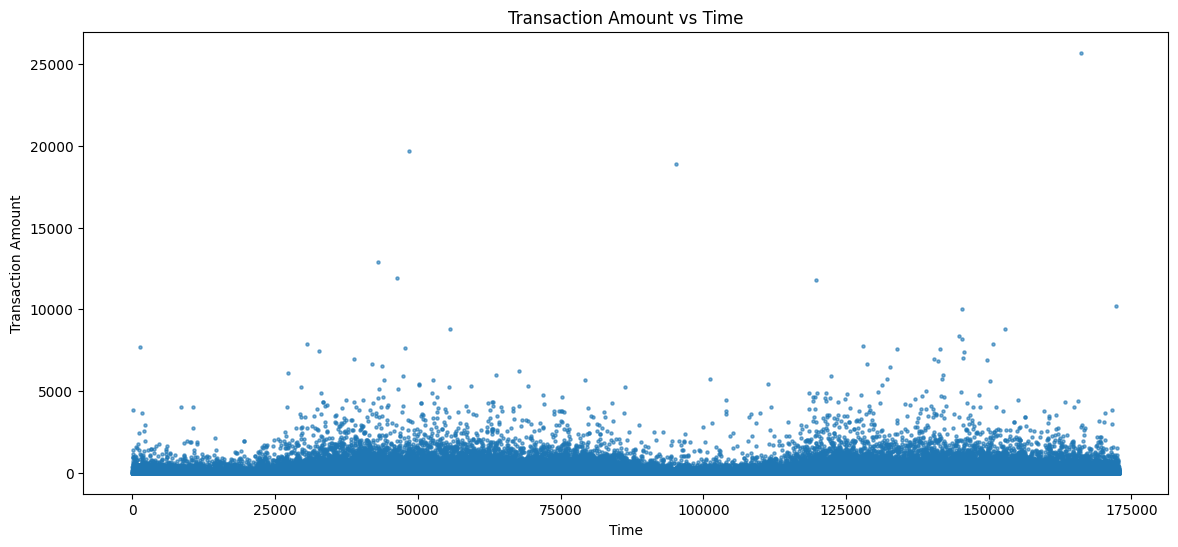

In [13]:
plt.figure(figsize=(14,6))

plt.scatter(
    df["Time"],
    df["Amount"],
    alpha=0.6,
    s=5
)

plt.xlabel("Time")

plt.ylabel("Transaction Amount")

plt.title("Transaction Amount vs Time")

plt.show()

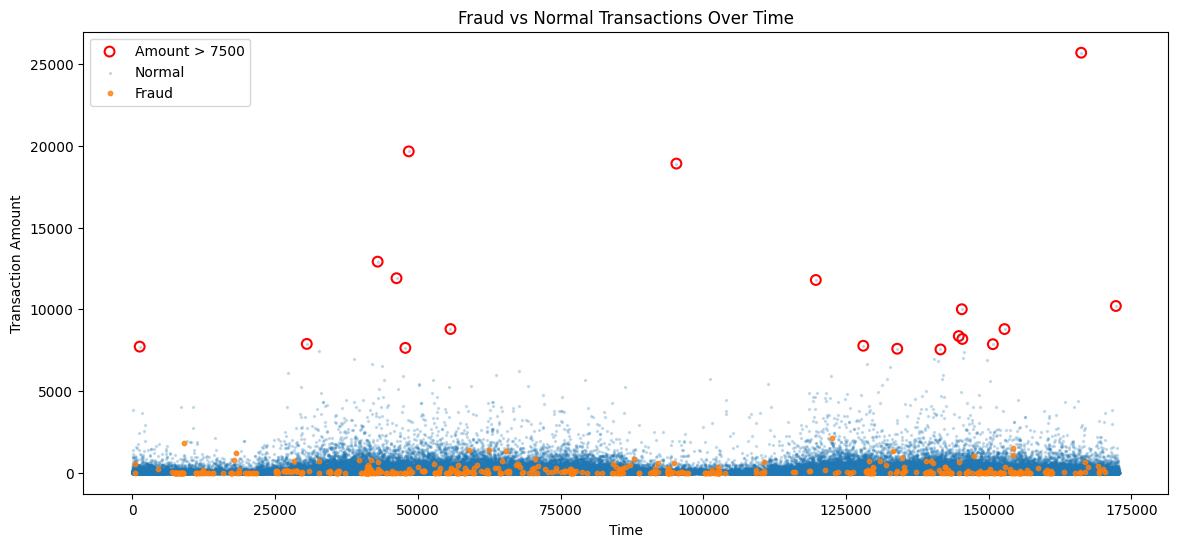

In [14]:
normal = df[df["Class"] == 0]
fraud = df[df["Class"] == 1]
high_amount = df[df["Amount"] > 7500]

plt.figure(figsize=(14,6))

plt.scatter(
    high_amount["Time"],
    high_amount["Amount"],
    facecolors="none",
    edgecolors="red",
    s=50,
    linewidths=1.5,
    label="Amount > 7500"
)

plt.scatter(
    normal["Time"],
    normal["Amount"],
    alpha=0.2,
    s=2,
    label="Normal"
)

plt.scatter(
    fraud["Time"],
    fraud["Amount"],
    alpha=0.8,
    s=10,
    label="Fraud"
)

plt.xlabel("Time")
plt.ylabel("Transaction Amount")
plt.title("Fraud vs Normal Transactions Over Time")

plt.legend()

plt.show()

In [15]:
df_fraud = df[df["Class"] == 1]
print(df_fraud[["Time", "Amount"]].describe())

                Time       Amount
count     473.000000   473.000000
mean    80450.513742   123.871860
std     48636.179973   260.211041
min       406.000000     0.000000
25%     41203.000000     1.000000
50%     73408.000000     9.820000
75%    129095.000000   105.890000
max    170348.000000  2125.870000


Observations:
 - Fraud cases do not exceed $2125. They do not happen in any of the outliers. Their median is 9.8 meaning they are all smaller transactions.
 - Fraud cases also have strong skewness meaning the outliers(close to $2k) are pulling the average up. 
 - Fraud cases are well spread within the timeline. No obvious bursts of fraud can be detected yet.

 Interesting observation:

* the extremely massive transactions are mostly non-fraudulent
* large transactions alone are NOT a fraud indicator

This is important because beginners often assume:

“higher amount = fraud”

Since fraud amounts are often small:

* Amount alone is weak
* PCA features likely matter much more
* Fraud behavior is probably hidden in transaction patterns rather than transaction size

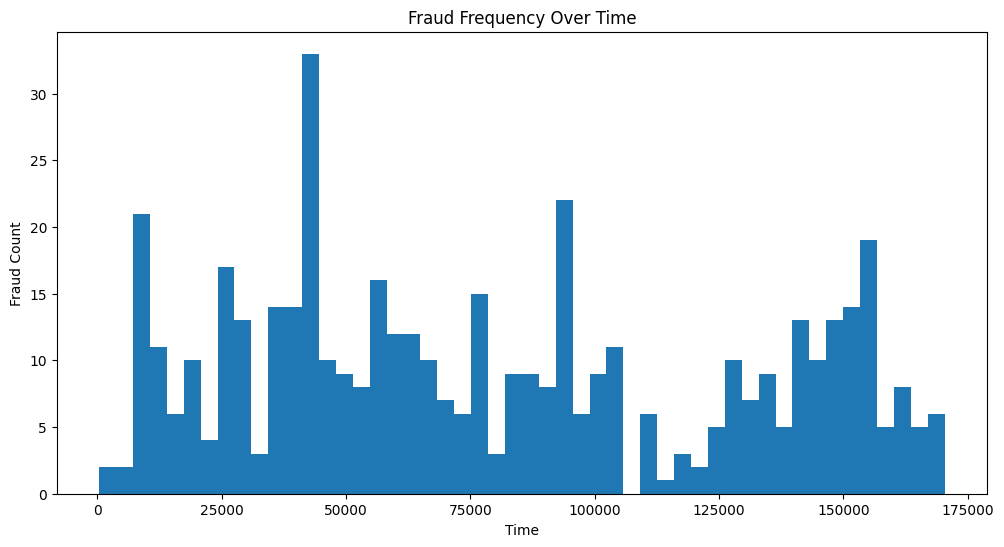

In [16]:
# Frequency Distribution of Fraudulent Transactions Over Time


fraud_df = df[df["Class"] == 1]

plt.figure(figsize=(12,6))

plt.hist(fraud_df["Time"], bins=50)

plt.xlabel("Time")
plt.ylabel("Fraud Count")
plt.title("Fraud Frequency Over Time")

plt.show()

/var/folders/68/hqh0xjgn4xs4b7b3wk_9jtn80000gn/T/ipykernel_4441/1062631699.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate = df.groupby("TimeBin")["Class"].mean()


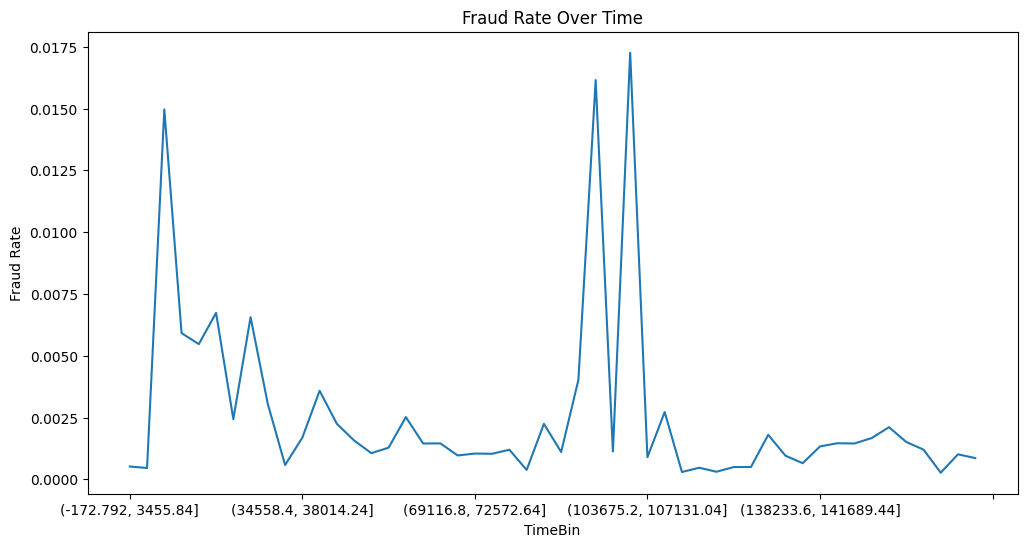

In [17]:
# create time bins
df["TimeBin"] = pd.cut(df["Time"], bins=50)

# fraud rate per bin
fraud_rate = df.groupby("TimeBin")["Class"].mean()

plt.figure(figsize=(12,6))

fraud_rate.plot()

plt.ylabel("Fraud Rate")
plt.title("Fraud Rate Over Time")

plt.show()

In [18]:
print(fraud_rate.sort_values(ascending=False).head(10))

TimeBin
(100219.36, 103675.2]    0.017257
(93307.68, 96763.52]     0.016149
(6911.68, 10367.52]      0.014966
(17279.2, 20735.04]      0.006734
(24190.88, 27646.72]     0.006559
(10367.52, 13823.36]     0.005914
(13823.36, 17279.2]      0.005469
(89851.84, 93307.68]     0.004024
(38014.24, 41470.08]     0.003583
(27646.72, 31102.56]     0.003043
Name: Class, dtype: float64


## Final Observations and Training Strategy

### Key Observations
- The dataset has no missing values.
- The target is extremely imbalanced, with fraud making up a very small fraction of the data.
- Exact duplicate rows exist and can leak information across splits, so the deduplicated dataset will be used for training.
- Removing duplicates reduces the fraud count from 492 to 473, so this choice should be kept in mind when comparing results with other work.
- `Amount` is highly right-skewed, with a small number of very large transactions.
- Fraudulent transactions are not simply the highest-amount transactions, so `Amount` alone is not a strong fraud signal.
- `Time` spans roughly 48 hours and fraud appears to be spread across the timeline, though some local variation in fraud rate exists.
- Since most useful features are anonymized PCA components, model performance will likely depend more on pattern learning than on manual feature interpretation.

### Training Direction
- Use the deduplicated dataset as the working dataset.
- Split the data into train, validation, and test sets using a stratified `75 / 15 / 10` split.
- Evaluate models using `recall`, `precision`, `F1`, `PR-AUC`, and `ROC-AUC`.
- Treat `PR-AUC` as the primary metric, while closely watching the precision-recall tradeoff.
- Start with a dummy baseline that predicts every transaction as non-fraud (`Class = 0`) to establish a reference point.
- Then train a first real baseline model using logistic regression.
- Compare the logistic regression model against the dummy baseline before trying more advanced methods.
- After that, consider threshold tuning and imbalance-handling methods such as class weighting before moving to more complex models.

## Export Useful Preprocessing Outputs

- Save the most useful preprocessing tables and plots into `outputs/preprocessing/` for later reference.

In [19]:
from pathlib import Path

output_dir = Path("../outputs/preprocessing")
output_dir.mkdir(parents=True, exist_ok=True)

# Save compact summary tables that are useful later.
class_distribution_df = pd.DataFrame({
    "count": df["Class"].value_counts().sort_index(),
    "proportion": df["Class"].value_counts(normalize=True).sort_index()
})
class_distribution_df.to_csv(output_dir / "class_distribution.csv")

duplicate_summary_df = pd.DataFrame([
    {
        "rows_after_deduplication": len(df),
        "non_fraud_count": int((df["Class"] == 0).sum()),
        "fraud_count": int((df["Class"] == 1).sum()),
        "fraud_proportion": float(df["Class"].mean())
    }
])
duplicate_summary_df.to_csv(output_dir / "deduplicated_dataset_summary.csv", index=False)

time_amount_summary_df = df[["Time", "Amount"]].describe().T
time_amount_summary_df.to_csv(output_dir / "time_amount_summary.csv")

fraud_time_amount_summary_df = df[df["Class"] == 1][["Time", "Amount"]].describe().T
fraud_time_amount_summary_df.to_csv(output_dir / "fraud_time_amount_summary.csv")

fraud_rate_table_df = fraud_rate.reset_index()
fraud_rate_table_df.columns = ["TimeBin", "FraudRate"]
fraud_rate_table_df.to_csv(output_dir / "fraud_rate_by_time_bin.csv", index=False)

top_fraud_rate_bins_df = fraud_rate.sort_values(ascending=False).head(10).reset_index()
top_fraud_rate_bins_df.columns = ["TimeBin", "FraudRate"]
top_fraud_rate_bins_df.to_csv(output_dir / "top_10_fraud_rate_bins.csv", index=False)

# Recreate and save the key plots so they are available outside the notebook.
plt.figure(figsize=(14, 6))
plt.scatter(df["Time"], df["Amount"], alpha=0.6, s=5)
plt.xlabel("Time")
plt.ylabel("Transaction Amount")
plt.title("Transaction Amount vs Time")
plt.tight_layout()
plt.savefig(output_dir / "amount_vs_time.png", dpi=300)
plt.close()

normal = df[df["Class"] == 0]
fraud = df[df["Class"] == 1]
high_amount = df[df["Amount"] > 7500]

plt.figure(figsize=(14, 6))
plt.scatter(high_amount["Time"], high_amount["Amount"], facecolors="none", edgecolors="red", s=50, linewidths=1.5, label="Amount > 7500")
plt.scatter(normal["Time"], normal["Amount"], alpha=0.2, s=2, label="Normal")
plt.scatter(fraud["Time"], fraud["Amount"], alpha=0.8, s=10, label="Fraud")
plt.xlabel("Time")
plt.ylabel("Transaction Amount")
plt.title("Fraud vs Normal Transactions Over Time")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "fraud_vs_normal_amount_time.png", dpi=300)
plt.close()

fraud_df = df[df["Class"] == 1]
plt.figure(figsize=(12, 6))
plt.hist(fraud_df["Time"], bins=50)
plt.xlabel("Time")
plt.ylabel("Fraud Count")
plt.title("Fraud Frequency Over Time")
plt.tight_layout()
plt.savefig(output_dir / "fraud_frequency_over_time.png", dpi=300)
plt.close()

plt.figure(figsize=(12, 6))
fraud_rate.plot()
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate Over Time")
plt.tight_layout()
plt.savefig(output_dir / "fraud_rate_over_time.png", dpi=300)
plt.close()

project_notes = """Preprocessing outputs saved from preprocessing.ipynb.

Key saved artifacts:
- class distribution after deduplication
- deduplicated dataset summary
- Time and Amount summary tables
- fraud-specific Time and Amount summary table
- fraud rate by time bin and top 10 highest bins
- key preprocessing plots for reuse in later analysis
"""

(output_dir / "preprocessing_notes.txt").write_text(project_notes)

print(f"Saved preprocessing outputs to: {output_dir.resolve()}")

Saved preprocessing outputs to: /Users/nidhushankanagaraja/Desktop/NYU/Personal/Learn/ML/Credit-Card-Fraud-Detection/outputs/preprocessing
